# Visualizzazione input rete FPR

Questo notebook mostra esattamente cosa riceve `FPReductionNet`: patch CT 3D normalizzata e vettore `meta` costruiti da `CandidatePatchDataset`.

Obiettivo: capire se il calo FROC dipende da input poco informativo/allineato, da labeling/candidate set, oppure dal rescoring/calibrazione dello score FPR.

In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

REPO_ROOT = Path.cwd()
while REPO_ROOT != REPO_ROOT.parent and not (REPO_ROOT / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.det.SCPMNet.fp_reduction import CandidatePatchDataset, ground_truth_by_series, label_candidates
from src.det.SCPMNet.dataset import load_volume, normalize_ct, pad_crop

plt.rcParams['figure.dpi'] = 120
REPO_ROOT

PosixPath('/Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis')

## Configurazione

Cambia `FOLD` e `SPLIT` per ispezionare altri casi. Di default usa le candidate Top100 FPR gia generate in `outputs/`.

In [2]:
FOLD = int(os.environ.get('FPR_FOLD', 1))
SPLIT = os.environ.get('FPR_SPLIT', 'test')

DATA_ROOT = Path(os.environ.get('LUNA16_PREPROCESSED', '/Users/domenicopaolo/Documents/datasets/LUNA16/LUNA16_preprocessed'))
if not DATA_ROOT.exists():
    DATA_ROOT = Path('/ssd2/domenico/datasets/LUNA16_preprocessed')

CSV_PATH = DATA_ROOT / 'cv_splits' / f'luna16_fold{FOLD}.csv'
CANDIDATES_CSV = REPO_ROOT / 'outputs' / 'scpmnet_luna16_10fold_fpr_top100' / f'scpmnet_paper_luna16_fold{FOLD}' / 'fp_reduction' / f'candidates_{SPLIT}_top100.csv'
RESCORED_CSV = REPO_ROOT / 'outputs' / 'scpmnet_luna16_10fold_fpr_top100' / f'scpmnet_paper_luna16_fold{FOLD}' / 'predictions' / f'{SPLIT}_predictions_rescored.csv'

print('DATA_ROOT:', DATA_ROOT, DATA_ROOT.exists())
print('CSV_PATH:', CSV_PATH, CSV_PATH.exists())
print('CANDIDATES_CSV:', CANDIDATES_CSV, CANDIDATES_CSV.exists())
print('RESCORED_CSV:', RESCORED_CSV, RESCORED_CSV.exists())

DATA_ROOT: /Users/domenicopaolo/Documents/datasets/LUNA16/LUNA16_preprocessed True
CSV_PATH: /Users/domenicopaolo/Documents/datasets/LUNA16/LUNA16_preprocessed/cv_splits/luna16_fold1.csv True
CANDIDATES_CSV: /Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/outputs/scpmnet_luna16_10fold_fpr_top100/scpmnet_paper_luna16_fold1/fp_reduction/candidates_test_top100.csv True
RESCORED_CSV: /Users/domenicopaolo/Documents/works/lung_ct_3d2d_synthesis/outputs/scpmnet_luna16_10fold_fpr_top100/scpmnet_paper_luna16_fold1/predictions/test_predictions_rescored.csv True


In [3]:
candidates = pd.read_csv(CANDIDATES_CSV)
print(candidates.shape)
display(candidates.head())

if 'label' not in candidates.columns:
    gt_for_labels = ground_truth_by_series(CSV_PATH, SPLIT, DATA_ROOT, skip_missing_images=False)
    candidates = label_candidates(candidates, gt_for_labels, ignore_margin=2.0)
    print('Added labels for visualization from GT annotations.')

if 'label' in candidates.columns:
    usable = candidates[~candidates.get('ignore', False).astype(bool)] if 'ignore' in candidates.columns else candidates
    print('Usable label counts:')
    display(usable['label'].value_counts().rename(index={0: 'negative', 1: 'positive'}))
    if 'ignore' in candidates.columns:
        print('Ignored:', int(candidates['ignore'].astype(bool).sum()))
if RESCORED_CSV.exists():
    rescored = pd.read_csv(RESCORED_CSV)
    print('Rescored:', rescored.shape)
    display(rescored[['probability', 'scpm_probability', 'classifier_probability']].describe())
else:
    rescored = None

(8881, 8)


,seriesuid,coordZ,coordY,coordX,radius,probability,candidate_rank,source_fold
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163...,211.382828,128.675186,90.530449,2.166412,0.483637,1,1
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163...,91.928474,130.365570,182.326630,3.746855,0.400249,2,1
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163...,209.974289,76.292183,153.453400,1.887106,0.392279,3,1
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163...,143.422028,64.637482,79.858841,3.004748,0.365245,4,1
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.100684836163...,181.626114,116.834602,76.669304,2.483401,0.358377,5,1


Added labels for visualization from GT annotations.
Usable label counts:


label
negative    8746
positive     129
Name: count, dtype: int64

Ignored: 6
Rescored: (8881, 8)


,probability,scpm_probability,classifier_probability
count,8881.000000,8881.000000,8881.000000
mean,0.034237,0.309785,0.100409
std,0.058016,0.078973,0.125092
min,0.000051,0.200275,0.000226
25%,0.003754,0.264242,0.012695
50%,0.013461,0.289192,0.045578
75%,0.043815,0.328804,0.147576
max,0.913696,0.939567,0.972465


## Dataset usato dalla rete FPR

`CandidatePatchDataset.__getitem__` restituisce:

- `image`: patch CT normalizzata, shape `[1, 32, 32, 32]`;
- `meta`: `[probability, radius / 32, z_norm, y_norm, x_norm]`;
- `label`: 1 se la candidate cade dentro il raggio GT, 0 altrimenti.

Per il test, se il CSV non ha label, il notebook crea una copia temporanea in memoria con label dummy per poter usare la stessa classe dataset.

In [4]:
tmp_path = REPO_ROOT / 'outputs' / '_tmp_fpr_visualization_candidates.csv'
candidates.to_csv(tmp_path, index=False)
dataset_csv = tmp_path

ds = CandidatePatchDataset(
    candidates_csv=dataset_csv,
    csv_path=CSV_PATH,
    split=SPLIT,
    data_root=DATA_ROOT,
    patch_size=(32, 32, 32),
    clip=(-1000.0, 400.0),
    include_ignored=True,
    augment=False,
    volume_cache_size=2,
)

print('Dataset length:', len(ds))
sample = ds[0]
print('image shape:', tuple(sample['image'].shape), 'range:', float(sample['image'].min()), float(sample['image'].max()))
print('meta:', sample['meta'].numpy())
print('label:', float(sample['label']))

Dataset length: 8881
image shape: (1, 32, 32, 32) range: 0.46857142448425293 0.7599999904632568
meta: [0.48363677 0.06770037 0.7658798  0.6246368  0.3621218 ]
label: 0.0


## Funzioni di visualizzazione

In [5]:
META_NAMES = ['score_orig', 'radius/32', 'z_norm', 'y_norm', 'x_norm']

def denorm_for_display(patch):
    arr = patch.squeeze().detach().cpu().numpy()
    return np.clip((arr + 1.0) / 2.0, 0.0, 1.0)

def show_patch_triplet(item, title='', ax_row=None):
    arr = denorm_for_display(item['image'])
    zc, yc, xc = [s // 2 for s in arr.shape]
    views = [arr[zc], arr[:, yc, :], arr[:, :, xc]]
    names = ['axial z=center', 'coronal y=center', 'sagittal x=center']
    if ax_row is None:
        fig, ax_row = plt.subplots(1, 3, figsize=(8, 2.6))
    for ax, img, name in zip(ax_row, views, names):
        ax.imshow(img, cmap='gray', vmin=0, vmax=1)
        ax.set_title(name, fontsize=8)
        ax.axis('off')
        ax.scatter([img.shape[1] / 2], [img.shape[0] / 2], c='cyan', s=12)
    if title:
        ax_row[0].text(0, -0.18, title, transform=ax_row[0].transAxes, fontsize=8, va='top')

def item_title(row, item=None):
    bits = [str(row.get('seriesuid', ''))[-18:]]
    if 'candidate_rank' in row:
        bits.append(f"rank={int(row['candidate_rank'])}")
    if 'label' in row:
        bits.append(f"label={int(row['label'])}")
    if 'ignore' in row:
        bits.append(f"ignore={bool(row['ignore'])}")
    bits.append(f"score={float(row.get('probability', np.nan)):.3f}")
    if 'nearest_gt_distance' in row and pd.notna(row['nearest_gt_distance']):
        bits.append(f"d_gt={float(row['nearest_gt_distance']):.1f}/r={float(row['nearest_gt_radius']):.1f}")
    if item is not None:
        meta = item['meta'].numpy()
        bits.append('meta=' + ', '.join(f'{n}:{v:.2f}' for n, v in zip(META_NAMES, meta)))
    return ' | '.join(bits)

def show_indices(indices, max_items=8):
    indices = list(indices)[:max_items]
    if not indices:
        print('No examples selected.')
        return
    fig, axes = plt.subplots(len(indices), 3, figsize=(9, 2.4 * len(indices)))
    if len(indices) == 1:
        axes = np.asarray([axes])
    for ax_row, idx in zip(axes, indices):
        item = ds[int(idx)]
        row = ds.candidates.iloc[int(idx)]
        show_patch_triplet(item, item_title(row, item), ax_row=ax_row)
    plt.tight_layout()

def nearest_dataset_indices(frame, n=6):
    # Map original row positions to dataset positions after CandidatePatchDataset filtering/reset.
    return frame.index[:n].tolist()

## Esempi positivi, negativi e casi borderline

Se il CSV contiene label, questi pannelli confrontano candidati positivi, falsi positivi lontani e candidati ignorati vicino al bordo della GT.

Top positive candidates


/var/folders/2m/517q_bv93nbbdqmt9c_qfc_c0000gn/T/ipykernel_3164/3090610549.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


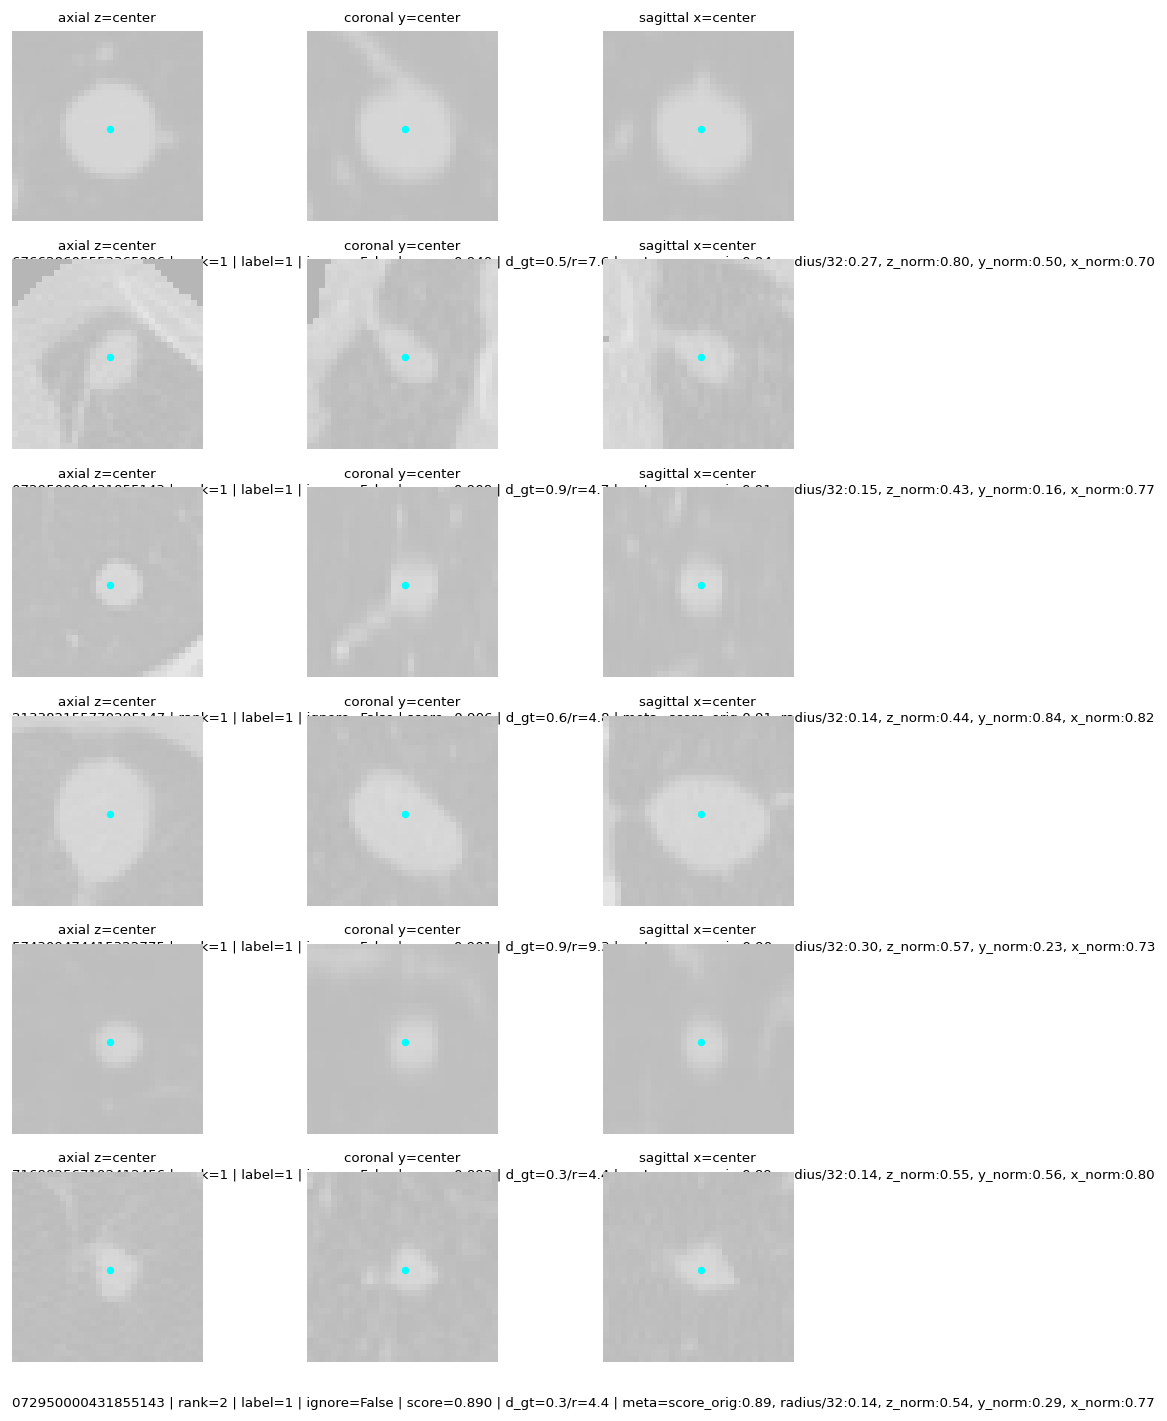

In [6]:
df_ds = ds.candidates.copy()

if 'label' in df_ds.columns:
    positives = df_ds[df_ds['label'].eq(1)].sort_values('probability', ascending=False)
    negatives_high = df_ds[df_ds['label'].eq(0)].sort_values('probability', ascending=False)
    ignored = df_ds[df_ds.get('ignore', False).astype(bool)] if 'ignore' in df_ds.columns else df_ds.iloc[0:0]

    print('Top positive candidates')
    show_indices(positives.index, max_items=6)
else:
    print('No labels available for this split.')

High-score negative candidates


/var/folders/2m/517q_bv93nbbdqmt9c_qfc_c0000gn/T/ipykernel_3164/3090610549.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


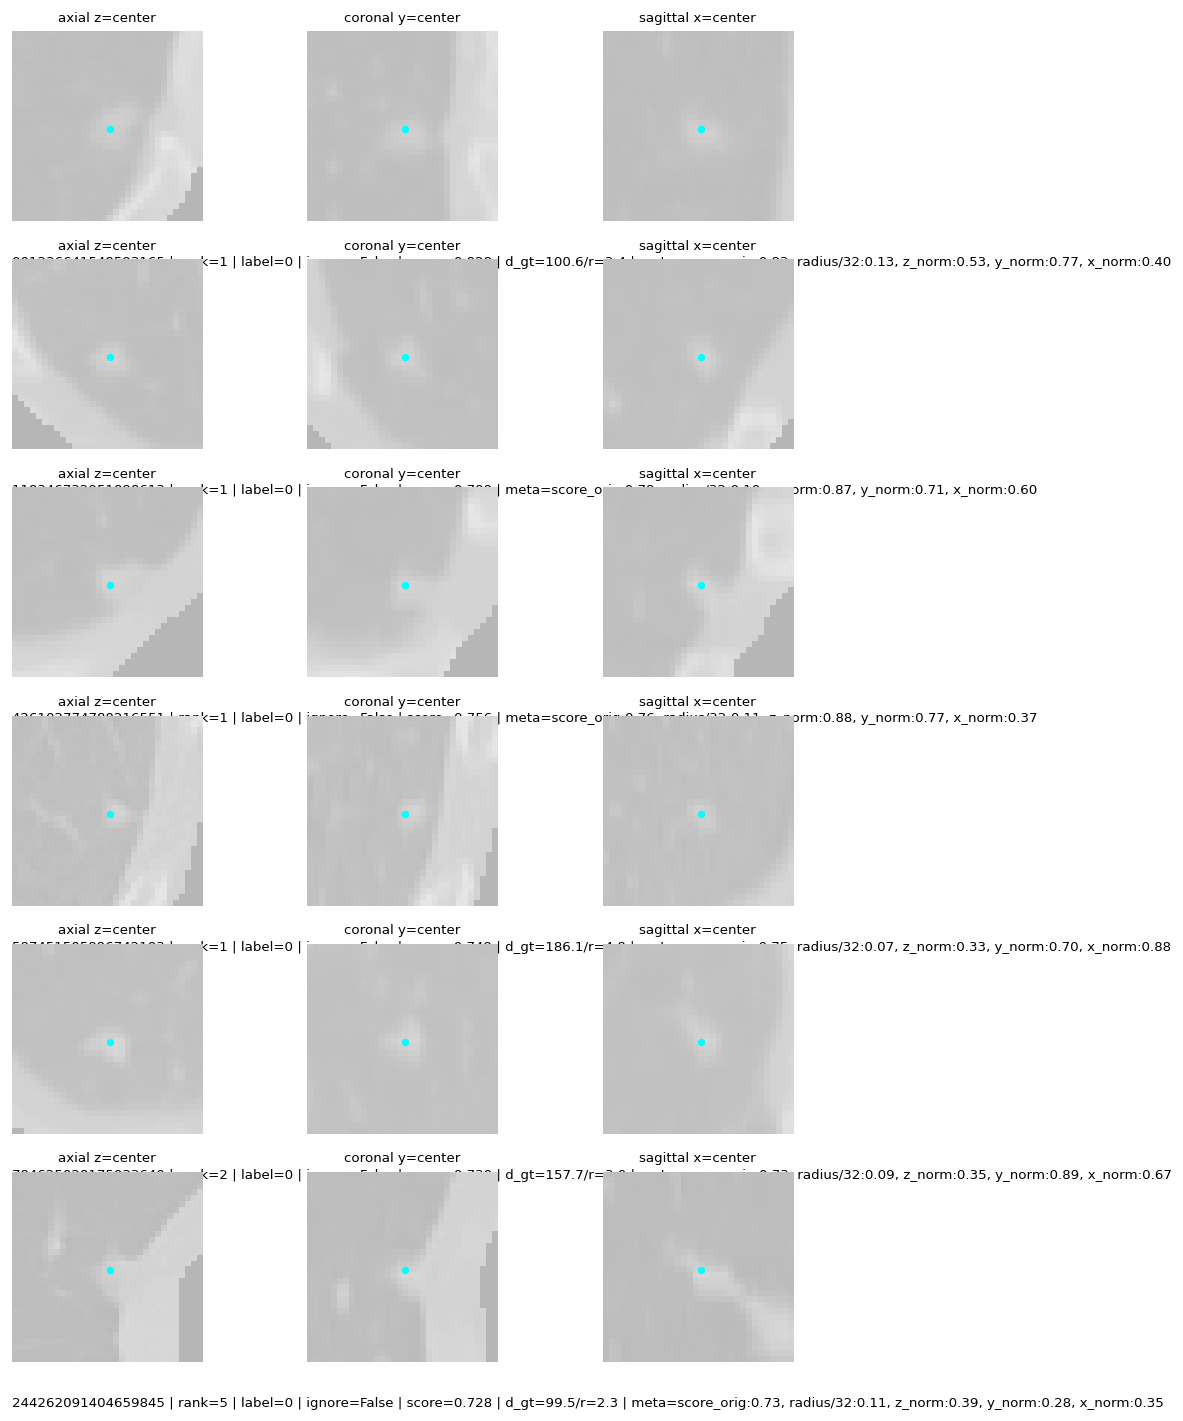

In [7]:
if 'label' in df_ds.columns:
    print('High-score negative candidates')
    show_indices(negatives_high.index, max_items=6)

Ignored/borderline candidates


/var/folders/2m/517q_bv93nbbdqmt9c_qfc_c0000gn/T/ipykernel_3164/3090610549.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


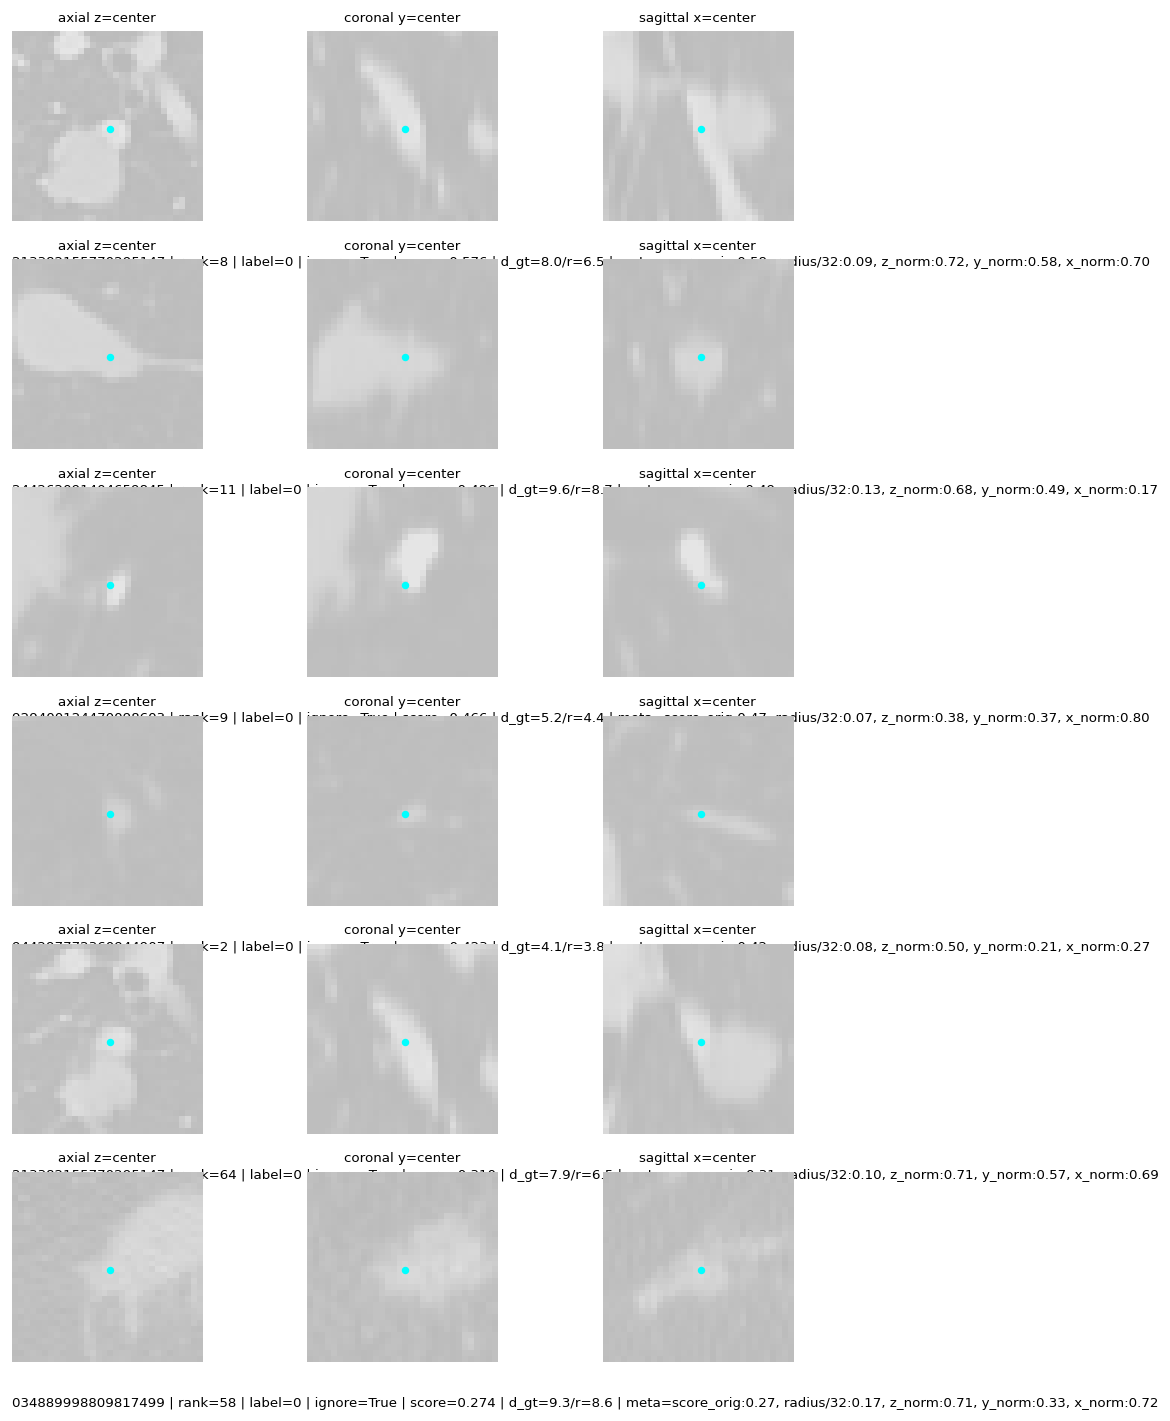

In [8]:
if 'label' in df_ds.columns and len(ignored):
    print('Ignored/borderline candidates')
    show_indices(ignored.sort_values('probability', ascending=False).index, max_items=6)
elif 'label' in df_ds.columns:
    print('No ignored candidates in this dataset view.')

## Se esiste il CSV rescored: esempi dove il classifier FPR penalizza candidati SCPMNet alti

Questa sezione e' utile per capire se il classifier sta abbassando veri positivi o alzando falsi positivi. I merge sono fatti per coordinate candidate.

In [9]:
if rescored is not None:
    key = ['seriesuid', 'coordZ', 'coordY', 'coordX', 'radius']
    merged = df_ds.reset_index(names='dataset_index').merge(
        rescored[key + ['scpm_probability', 'classifier_probability', 'probability']],
        on=key,
        how='left',
        suffixes=('', '_rescored'),
    )
    merged['penalty'] = merged['scpm_probability'] - merged['probability_rescored']
    display(merged[['label', 'ignore', 'probability', 'scpm_probability', 'classifier_probability', 'probability_rescored', 'penalty']].describe())
else:
    merged = None
    print('No rescored CSV found.')

,label,probability,scpm_probability,classifier_probability,probability_rescored,penalty
count,8881.000000,8881.000000,6923.000000,6923.000000,6923.000000,6923.000000
mean,0.014525,0.309785,0.309654,0.098729,0.033724,0.275930
std,0.119650,0.078973,0.078031,0.125564,0.058613,0.064031
min,0.000000,0.200275,0.200513,0.000226,0.000051,0.025871
25%,0.000000,0.264242,0.264159,0.011689,0.003473,0.237974
50%,0.000000,0.289192,0.289661,0.043139,0.012839,0.267986
75%,0.000000,0.328804,0.329427,0.142258,0.043002,0.304860
max,1.000000,0.939567,0.939567,0.972465,0.913696,0.751460


Positive candidates most penalized by multiply rescoring


/var/folders/2m/517q_bv93nbbdqmt9c_qfc_c0000gn/T/ipykernel_3164/3090610549.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


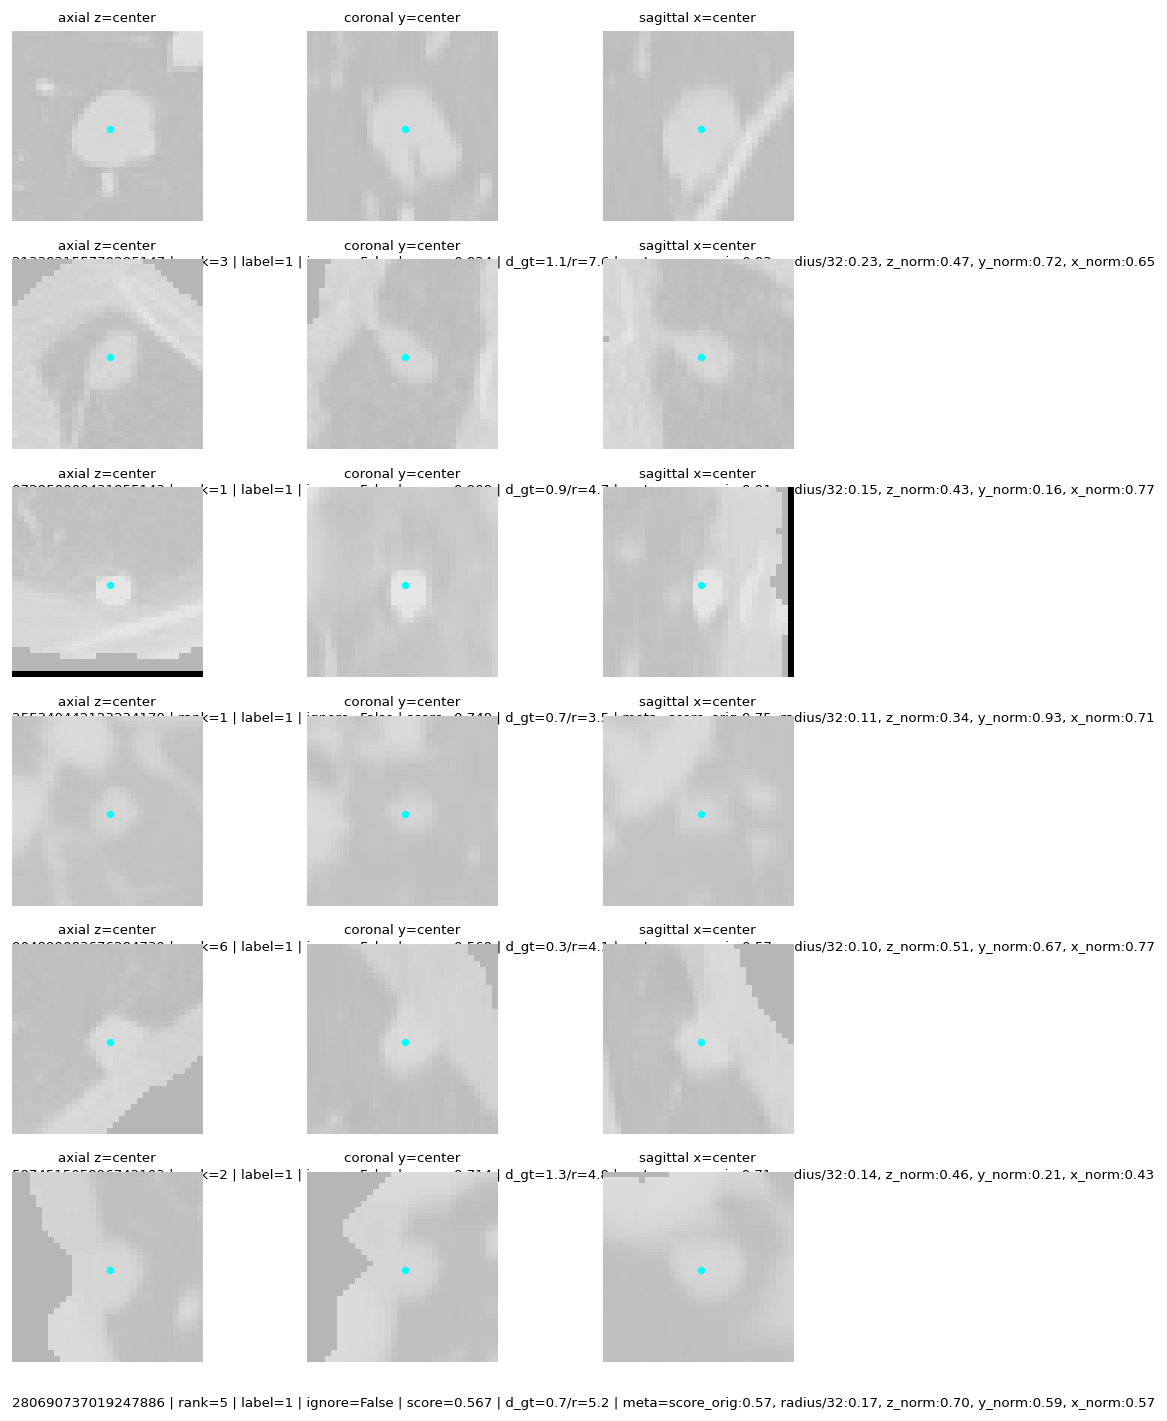

In [10]:
if merged is not None and 'label' in merged.columns:
    hard_tp_penalized = merged[merged['label'].eq(1)].sort_values('penalty', ascending=False)
    print('Positive candidates most penalized by multiply rescoring')
    show_indices(hard_tp_penalized['dataset_index'].head(6), max_items=6)

Negative candidates with highest classifier_probability


/var/folders/2m/517q_bv93nbbdqmt9c_qfc_c0000gn/T/ipykernel_3164/3090610549.py:50: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


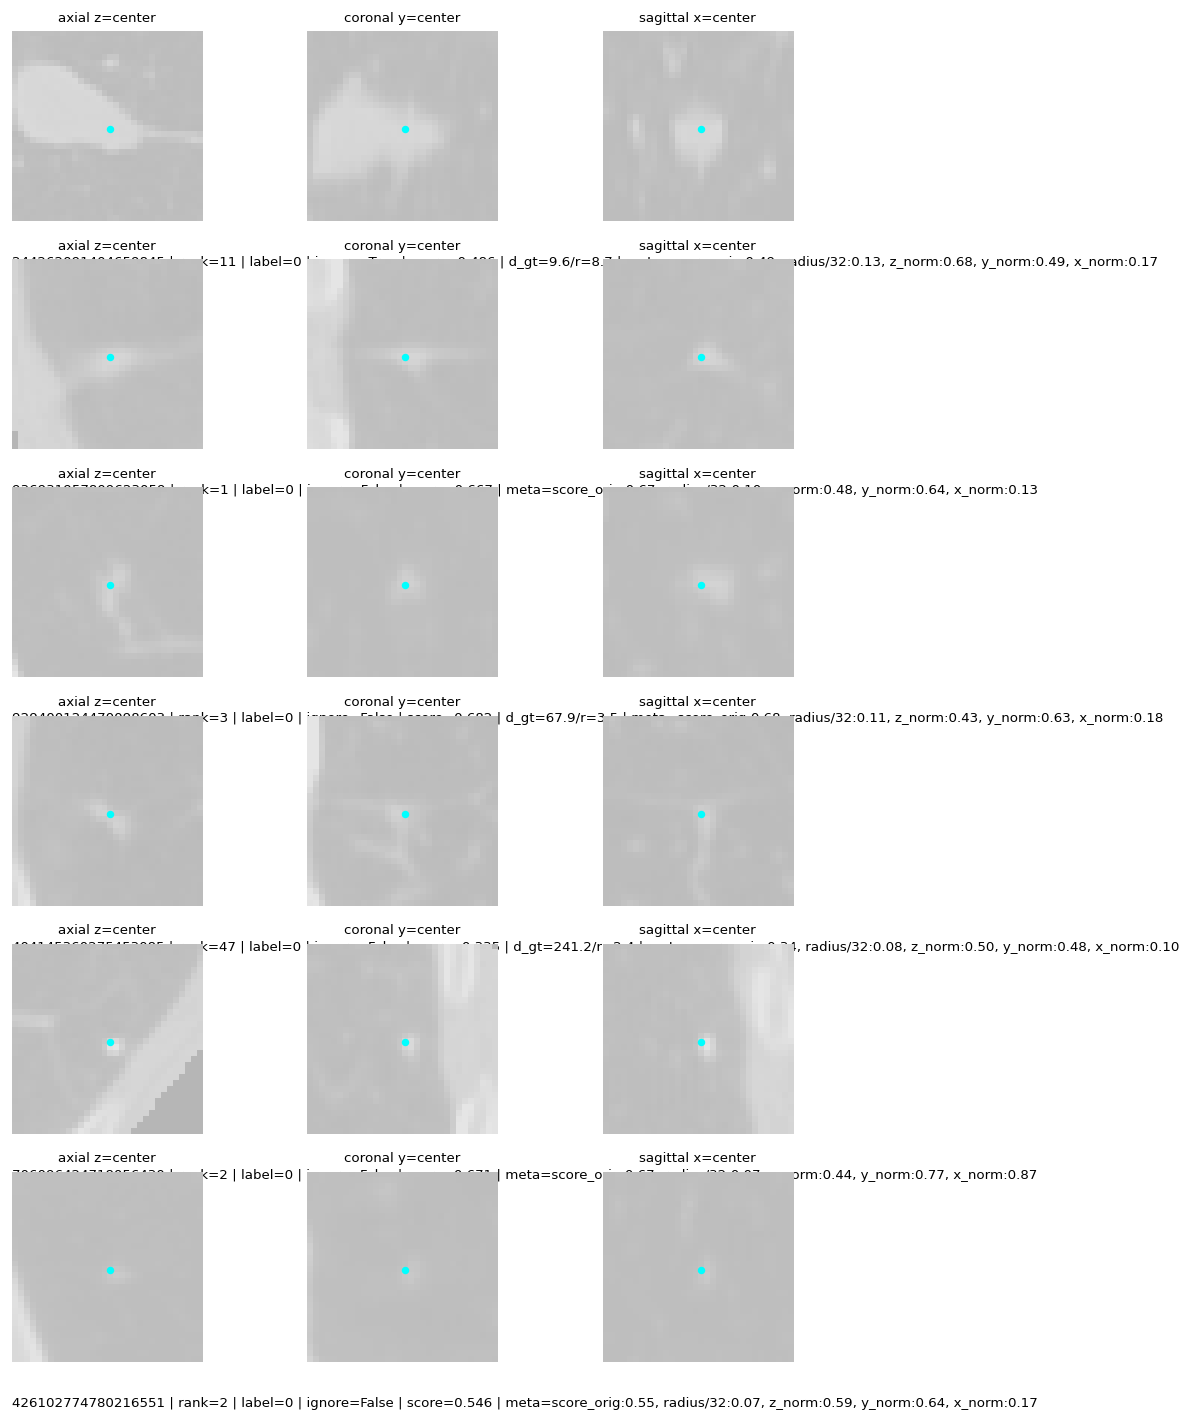

In [11]:
if merged is not None and 'label' in merged.columns:
    fp_high_classifier = merged[merged['label'].eq(0)].sort_values('classifier_probability', ascending=False)
    print('Negative candidates with highest classifier_probability')
    show_indices(fp_high_classifier['dataset_index'].head(6), max_items=6)

## Controllo allineamento sul volume intero

Questa cella mostra la slice CT originale della candidate con marker sul centro e, se disponibili, i centri GT sulla stessa slice. Serve per verificare se la patch e' centrata dove ci aspettiamo.

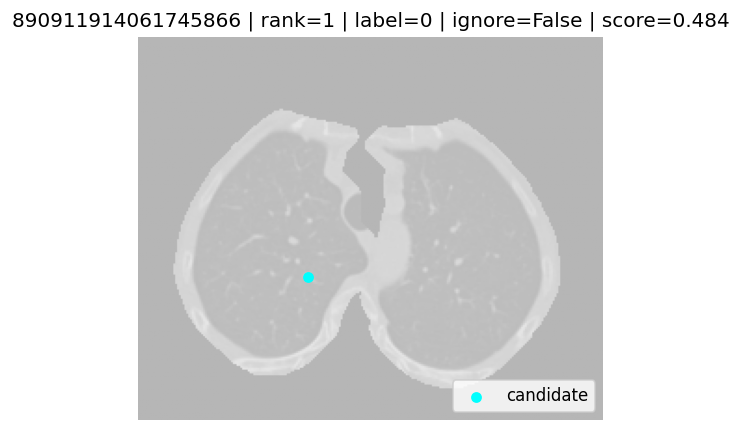

In [12]:
GT = ground_truth_by_series(CSV_PATH, SPLIT, DATA_ROOT, skip_missing_images=False)

def show_volume_context(dataset_index=0, window=(-1000.0, 400.0)):
    row = ds.candidates.iloc[int(dataset_index)]
    seriesuid = str(row['seriesuid'])
    volume = normalize_ct(load_volume(ds.image_paths[seriesuid]), window)
    z, y, x = row[['coordZ', 'coordY', 'coordX']].to_numpy(dtype=float)
    zi = int(round(np.clip(z, 0, volume.shape[0] - 1)))
    image = np.clip((volume[zi] + 1.0) / 2.0, 0.0, 1.0)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(image, cmap='gray', vmin=0, vmax=1)
    ax.scatter([x], [y], c='cyan', s=30, label='candidate')
    gt = GT.get(seriesuid, np.zeros((0, 4), dtype=np.float32))
    if len(gt):
        close = np.abs(gt[:, 0] - zi) <= np.maximum(gt[:, 3], 2.0)
        ax.scatter(gt[close, 2], gt[close, 1], c='yellow', s=20, label='GT near slice')
    ax.set_title(item_title(row))
    ax.legend(loc='lower right')
    ax.axis('off')
    plt.show()

show_volume_context(0)

## Cosa guardare

- Se le patch positive non contengono visivamente il nodulo al centro, il problema e' input/cropping/coordinate.
- Se le patch positive sono buone ma il classifier le penalizza, il problema e' training/calibrazione dello score FPR.
- Se molti negativi high-score somigliano ai positivi o contengono strutture pleuriche/vasi forti, il classifier potrebbe aver bisogno di patch piu grandi, feature contestuali o loss/ranking loss diversa.
- Se `meta['score_orig']` domina rispetto all'immagine, provare score fusion validata su FROC invece di `multiply` fisso.